In [9]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Samuel\OneDrive\Bureau\MASTER 1\Technologies de Conteneurisation\Projet_Final\data\city_lifestyle_dataset.csv")
df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [10]:
from sklearn.preprocessing import StandardScaler

X = df.drop(["city_name", "country"], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

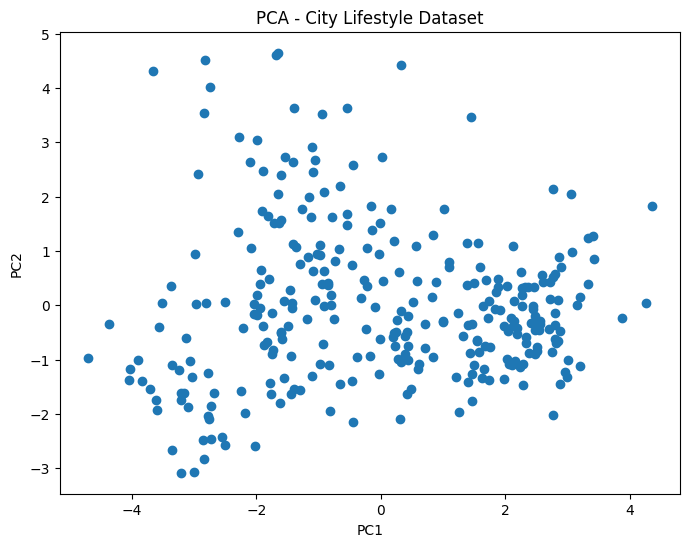

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA - City Lifestyle Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [13]:
print(pca.explained_variance_ratio_)

[0.53805804 0.25833116]


L’analyse en composantes principales montre que la première composante (PC1) explique environ **53,8 %** de la variance totale, tandis que la seconde (PC2) en explique **25,8 %**. Au total, les deux premières composantes résument donc près de **79,6 % de l’information du jeu de données**, ce qui est très satisfaisant. Cela signifie que la représentation en deux dimensions conserve l’essentiel de la structure des données et permet une visualisation fiable.

En observant le graphique, on distingue plusieurs regroupements de points, ce qui suggère l’existence de groupes naturels de villes ayant des caractéristiques similaires. Certains ensembles semblent particulièrement séparés le long de l’axe principal (PC1), indiquant que cette composante joue un rôle majeur dans la différenciation des villes. On peut supposer que cet axe est lié à un niveau global de développement ou de richesse, notamment si les variables économiques (revenu, PIB, coût de la vie, infrastructures) contribuent fortement à cette composante.

Ainsi, la PCA met en évidence une structuration claire des villes et laisse penser que les villes les plus riches ou développées tendent à se regrouper et à se distinguer des autres. Cette première analyse confirme donc la pertinence d’une approche de segmentation sur ce jeu de données.


In [14]:
import os
import pandas as pd
import numpy as np

# Créer le dossier s'il n'existe pas
os.makedirs("../outputs", exist_ok=True)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df.to_csv("../outputs/pca_emb_2d.csv", index=False)